In [ ]:
import qiskit
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister
from qiskit.visualization import plot_histogram,plot_distribution
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit_aer import Aer, AerSimulator
from qiskit.circuit.library import UGate
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import pylatexenc
import numpy as np
import math

### Optomechanical System

In [ ]:
def build_circuit(eps, troter_steps):
    # DEFINE VARIABLES
    gup_coeff = 0.001
    w0 = 1 - (2 * gup_coeff)
    w1 = math.sqrt(2) - (4 * gup_coeff)
    u0 = 1
    u1 = math.sqrt(2)
    theta_1 = (w0 * u0 * eps)
    theta_2 = (w0 * u1 * eps)
    theta_3 = (w1 * u0 * eps)
    theta_4 = (w1 * u1 * eps)
    # print(theta_1, theta_2, theta_3, theta_4)
    # FOR TROTTERIZATION
    dtheta_1 = theta_1 / troter_steps
    dtheta_2 = theta_2 / troter_steps
    dtheta_3 = theta_3 / troter_steps
    dtheta_4 = theta_4 / troter_steps
    b0 = QuantumRegister(1, "b0")
    b1 = QuantumRegister(1,"b1")
    b2 = QuantumRegister(1,"b2")

    a0 = QuantumRegister(1, "a0")
    a1 = QuantumRegister(1,"a1")
    a2 = QuantumRegister(1,"a2")
    creg = ClassicalRegister(6,name = "measurement")
    quantum_circuit = QuantumCircuit(b0,a0,b1,a1,b2,a2,creg)
    # INITIAL STATE PREPARATION
    alpha = 1 / np.sqrt(1 + (gup_coeff**2)/2)
    beta  = (gup_coeff / np.sqrt(2)) / np.sqrt(1 + (gup_coeff**2)/2)
    # exact rotation angle
    theta_prep = 2 * np.arcsin(beta)
    quantum_circuit.x(0)  # b-register vacuum |100>
    quantum_circuit.x(1)  # a-register vacuum |100>
    quantum_circuit.cry(theta_prep, 0, 4)
    quantum_circuit.cx(4, 0)
    # FIRST BLOCK H00
    # STRING 1
    for _ in range(troter_steps):
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2, b0)

        quantum_circuit.p(dtheta_1,b0)

        quantum_circuit.rx(-np.pi/2, b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        # barrier
        # quantum_circuit.barrier(label = "1.2")
        # STRING 2
        quantum_circuit.s(a1)
        quantum_circuit.s(a0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2, b0)

        quantum_circuit.p(dtheta_1,b0)

        quantum_circuit.rx(-np.pi/2, b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(a0)
        quantum_circuit.sdg(a1)
        # barrier
        # quantum_circuit.barrier(label = "2.3")
        # STRING 3
        quantum_circuit.s(b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2,b0)

        quantum_circuit.p(dtheta_1, b0)

        quantum_circuit.rx(-np.pi/2,b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.sdg(b1)
        # barrier
        # quantum_circuit.barrier(label = "3.4")
        # STRING 4
        quantum_circuit.s(a1)
        quantum_circuit.s(b1)
        quantum_circuit.s(a0)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2,b0)

        quantum_circuit.p(dtheta_1, b0)

        quantum_circuit.rx(-np.pi/2,b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.sdg(a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(a1)
        # Barrier
        # quantum_circuit.barrier(label = "BLOCK 2")
        # BLOCK 2
        # STRING 1
        quantum_circuit.cx(b0,a2)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2, b0)

        quantum_circuit.p(dtheta_2,b0)

        quantum_circuit.rx(-np.pi/2, b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a2)
        # BARRIER
        # quantum_circuit.barrier(label = "1.2")
        # STRING 2
        quantum_circuit.s(a2)
        quantum_circuit.s(a1)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2, b0)

        quantum_circuit.p(dtheta_2,b0)

        quantum_circuit.rx(-np.pi/2, b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.sdg(a1)
        quantum_circuit.sdg(a2)
        # BARRIER 
        # quantum_circuit.barrier(label = "2.3")
        # STRING 3
        quantum_circuit.s(b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2,b0)

        quantum_circuit.p(dtheta_2, b0)

        quantum_circuit.rx(-np.pi/2,b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.sdg(b0)
        quantum_circuit.sdg(b1)
        # BARRIER 
        # quantum_circuit.barrier(label = "3.4")
        # STRING 4
        quantum_circuit.s(a2)
        quantum_circuit.s(b1)
        quantum_circuit.s(a1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.s(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.s(b0)
        quantum_circuit.rx(np.pi/2,b0)

        quantum_circuit.p(dtheta_2, b0)

        quantum_circuit.rx(-np.pi/2,b0)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,b1)
        quantum_circuit.sdg(b0)
        quantum_circuit.cx(b0,a2)
        quantum_circuit.sdg(b0)
        quantum_circuit.sdg(a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(a2)
        # BARRIER
        # quantum_circuit.barrier(label = "Block 3")
        # BLOCK 3
        # STRING 1
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2, b1)

        quantum_circuit.p(dtheta_3,b1)

        quantum_circuit.rx(-np.pi/2, b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        # barrier
        # quantum_circuit.barrier(label = "1.2")
        # STRING 2
        quantum_circuit.s(a1)
        quantum_circuit.s(a0)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2, b1)

        quantum_circuit.p(dtheta_3,b1)

        quantum_circuit.rx(-np.pi/2, b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(a0)
        quantum_circuit.sdg(a1)
        # barrier
        # quantum_circuit.barrier(label = "2.3")
        # STRING 3
        quantum_circuit.s(b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2,b1)

        quantum_circuit.p(dtheta_3, b1)

        quantum_circuit.rx(-np.pi/2,b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(b2)
        # barrier
        # quantum_circuit.barrier(label = "3.4")
        # STRING 4
        quantum_circuit.s(a1)
        quantum_circuit.s(b2)
        quantum_circuit.s(a0)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2,b1)

        quantum_circuit.p(dtheta_3, b1)

        quantum_circuit.rx(-np.pi/2,b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a0)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(a0)
        quantum_circuit.sdg(b2)
        quantum_circuit.sdg(a1)
        # Barrier 
        # quantum_circuit.barrier(label = "Block 4")
        # BLOCK 4
        # STRING 1
        quantum_circuit.cx(b1,a2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2, b1)

        quantum_circuit.p(dtheta_4,b1)

        quantum_circuit.rx(-np.pi/2, b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a2)
        # barrier
        # quantum_circuit.barrier(label = "1.2")
        # STRING 2
        quantum_circuit.s(a2)
        quantum_circuit.s(a1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2, b1)

        quantum_circuit.p(dtheta_4,b1)

        quantum_circuit.rx(-np.pi/2, b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.sdg(a1)
        quantum_circuit.sdg(a2)
        # barrier
        # quantum_circuit.barrier(label = "2.3")
        # STRING 3
        quantum_circuit.s(b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2,b1)

        quantum_circuit.p(dtheta_4, b1)

        quantum_circuit.rx(-np.pi/2,b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(b2)
        # barrier
        # quantum_circuit.barrier(label = "3.4")
        # STRING 4
        quantum_circuit.s(a2)
        quantum_circuit.s(b2)
        quantum_circuit.s(a1)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.s(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.s(b1)
        quantum_circuit.rx(np.pi/2,b1)

        quantum_circuit.p(dtheta_4, b1)

        quantum_circuit.rx(-np.pi/2,b1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a1)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,b2)
        quantum_circuit.sdg(b1)
        quantum_circuit.cx(b1,a2)
        quantum_circuit.sdg(b1)
        quantum_circuit.sdg(a1)
        quantum_circuit.sdg(b2)
        quantum_circuit.sdg(a2)
    quantum_circuit.measure([0,1,2,3,4,5],[0,1,2,3,4,5])
    quantum_circuit.draw('mpl', fold = 51)
    plt.show()
    return quantum_circuit
# eps_list = [0.001,0.002,0.003,0.004,0.005,0.006] # math.pow(10,-3), math.pow(10,-5) 
# eps_list =  np.linspace(0.15, 0.25, 25).tolist()
eps_list = 0.15
troter_steps = 1

Counts: {'001': 447, '100': 211, '010': 366}


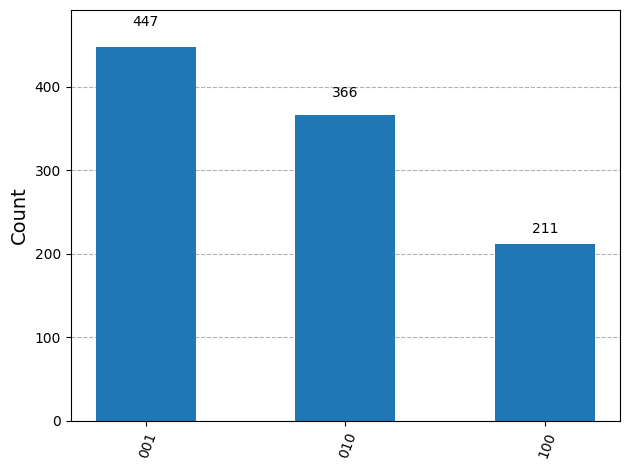

In [ ]:
results = []
quantum_circuit = build_circuit(eps_list, troter_steps)
print ("circuit_depth = ", quantum_circuit.depth())
print("Circuit size = ", quantum_circuit.size())
backend = AerSimulator()
transpiled_circuit = transpile(quantum_circuit, backend)
print("Transpiled depth:", transpiled_circuit.depth())

sampler = Sampler(mode=backend)
result = sampler.run([transpiled_circuit], shots=1024).result()

counts = result[0].data.measurement.get_counts()

print("Counts:", counts)
# results[troter_steps][eps] = counts
# print(results[troter_steps])
plot_histogram(counts)